In [44]:
# imports

import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.manifold import TSNE

import brain_observatory_utilities.datasets.optical_physiology.data_formatting as ophys_formatting
import brain_observatory_utilities.utilities.general_utilities as utilities

from allensdk.brain_observatory.behavior.behavior_project_cache import VisualBehaviorOphysProjectCache

import warnings
warnings.filterwarnings('ignore')

In [45]:
# read data from cache
# or download if necessary

data_storage_directory = "./tmp"  # Note: this path must exist on your local drive
cache = VisualBehaviorOphysProjectCache.from_s3_cache(cache_dir=data_storage_directory)

session_table = cache.get_ophys_session_table()
experiment_table = cache.get_ophys_experiment_table()

In [46]:
# how many mice?
len(np.unique(session_table.mouse_id))

107

In [47]:
# how many sessions per mouse?

session_counts = {}

for mouse_id in np.unique(session_table.mouse_id):
    sessions_for_mouse = session_table[session_table.mouse_id == mouse_id]
    session_counts[mouse_id] = len(sessions_for_mouse)

min(session_counts.values()), max(session_counts.values())

(4, 11)

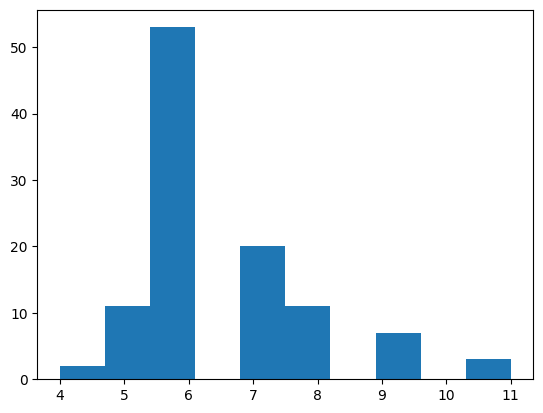

In [48]:
plt.hist(session_counts.values());

In [49]:
ophys_session_ids = np.array(session_table.index)
# there are no duplicate session ids
assert len(ophys_session_ids) == len(np.unique(ophys_session_ids))

len(ophys_session_ids)

705

In [50]:
experiments_per_session = {}

for session_id in ophys_session_ids:
    experiment_count = len(experiment_table[experiment_table.ophys_session_id == session_id])
    experiments_per_session[session_id] = experiment_count

min(experiments_per_session.values()), max(experiments_per_session.values())

(0, 8)

In [51]:
# downloading experiments or loading from cache
ophys_session_id = ophys_session_ids[0]
experiments = {}
ophys_experiment_ids = session_table.loc[ophys_session_id]['ophys_experiment_id']
for ophys_experiment_id in ophys_experiment_ids:
    print(f"Downloading experiment #{ophys_experiment_id}...")
    experiments[ophys_experiment_id] = cache.get_behavior_ophys_experiment(ophys_experiment_id)

In [52]:
# downloading experiments or loading from cache
def load_experiments(ophys_session_id: int) -> dict:
    experiments = {}
    ophys_experiment_ids = session_table.loc[ophys_session_id]['ophys_experiment_id']
    for ophys_experiment_id in ophys_experiment_ids:
        print(f"Downloading experiment #{ophys_experiment_id}...")
        experiments[ophys_experiment_id] = cache.get_behavior_ophys_experiment(ophys_experiment_id)
    return experiments

In [53]:
list(experiments.values())[0].stimulus_templates

,unwarped,warped
image_name,,
im065,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[198, 197, 201, 207, 207, 202, 198, 201, 207,..."
im077,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[129, 135, 140, 142, 140, 135, 129, 124, 117,..."
im066,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[83, 85, 82, 78, 78, 81, 84, 84, 82, 82, 84, ..."
im061,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[125, 126, 126, 126, 125, 125, 125, 125, 125,..."
im063,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[105, 108, 107, 101, 97, 96, 98, 101, 103, 10..."
im062,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[103, 103, 103, 105, 112, 125, 145, 172, 204,..."
im085,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[54, 56, 50, 45, 45, 51, 56, 55, 51, 48, 49, ..."
im069,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[251, 248, 255, 255, 255, 254, 246, 248, 255,..."


In [54]:
first_experiment = list(experiments.values())[0]
first_experiment_obj = list(experiments.values())[0]

In [55]:
list(experiments.values())[0]

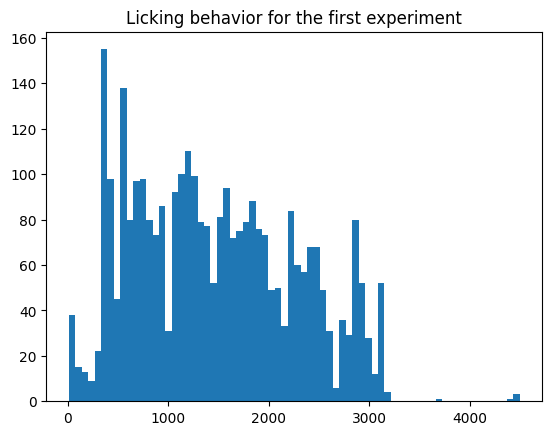

In [56]:
licks = first_experiment.licks
timestamps = licks['timestamps']

plt.title('Licking behavior for the first experiment')
plt.hist(timestamps, bins=70);

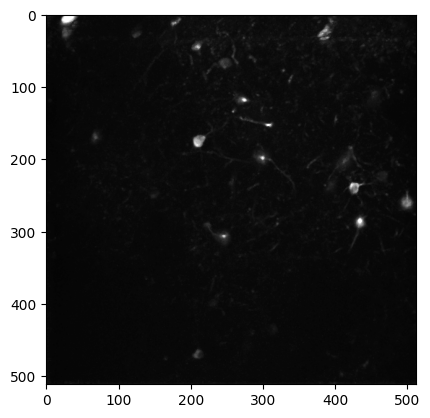

In [57]:
plt.imshow(first_experiment.max_projection, cmap="gray");

In [58]:
list(experiments.values())[0].trials[["initial_image_name", "change_image_name"]]

,initial_image_name,change_image_name
trials_id,,
0,im065,im065
1,im065,im065
2,im065,im065
3,im065,im065
4,im065,im069
...,...,...
754,im085,im066
755,im066,im085
756,im085,im077


In [59]:
np.unique(list(experiments.values())[0].trials[['initial_image_name']])

array(['im061', 'im062', 'im063', 'im065', 'im066', 'im069', 'im077',
       'im085'], dtype=object)

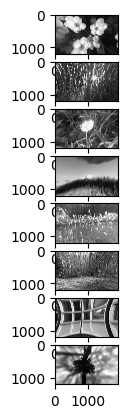

In [60]:
fig, ax = plt.subplots(len(first_experiment.stimulus_templates.warped))

for i, img in enumerate(first_experiment.stimulus_templates.warped):
    ax[i].imshow(img, cmap="gray")

In [61]:
neural_data = ophys_formatting.build_tidy_cell_df(first_experiment)
neural_data

,timestamps,dff,events,filtered_events,cell_roi_id,cell_specimen_id
0,9.26356,0.936573,0.000000,0.000000,1080743723,1086613265
1,9.35677,0.582486,0.000000,0.000000,1080743723,1086613265
2,9.44998,1.296005,0.556873,0.400762,1080743723,1086613265
3,9.54318,0.844898,0.000000,0.148502,1080743723,1086613265
4,9.63639,1.181188,0.467264,0.343829,1080743723,1086613265
...,...,...,...,...,...,...
48311,4513.43879,1.033316,0.499144,0.359216,1080743847,1086616398
48312,4513.53202,1.681890,0.787122,0.699572,1080743847,1086616398
48313,4513.62526,2.074159,0.691039,0.713992,1080743847,1086616398
48314,4513.71849,1.668930,0.000000,0.195007,1080743847,1086616398


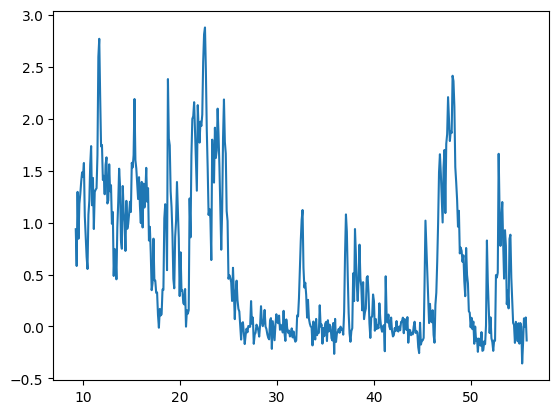

In [62]:
asdfasdf = neural_data[neural_data['cell_specimen_id'] == 1086613265][['timestamps', 'dff']]
plt.plot(asdfasdf['timestamps'][:500], asdfasdf['dff'][:500])

In [87]:
from allensdk.core.brain_observatory_cache import BrainObservatoryCache

boc = BrainObservatoryCache(manifest_file="boc_manifest.json")

cu2_ecs = boc.get_experiment_containers(cre_lines=['Cux2-CreERT2'])


[{'id': 511510736,
  'imaging_depth': 175,
  'targeted_structure': 'VISp',
  'cre_line': 'Cux2-CreERT2',
  'reporter_line': 'Ai93(TITL-GCaMP6f)',
  'donor_name': '222426',
  'specimen_name': 'Cux2-CreERT2;Camk2a-tTA;Ai93-222426',
  'tags': [],
  'failed': False},
 {'id': 511854338,
  'imaging_depth': 275,
  'targeted_structure': 'VISal',
  'cre_line': 'Cux2-CreERT2',
  'reporter_line': 'Ai93(TITL-GCaMP6f)',
  'donor_name': '233215',
  'specimen_name': 'Cux2-CreERT2;Camk2a-tTA;Ai93-233215',
  'tags': [],
  'failed': False},
 {'id': 511510855,
  'imaging_depth': 175,
  'targeted_structure': 'VISp',
  'cre_line': 'Cux2-CreERT2',
  'reporter_line': 'Ai93(TITL-GCaMP6f)',
  'donor_name': '229106',
  'specimen_name': 'Cux2-CreERT2;Camk2a-tTA;Ai93-229106',
  'tags': [],
  'failed': False},
 {'id': 658854535,
  'imaging_depth': 175,
  'targeted_structure': 'VISpm',
  'cre_line': 'Cux2-CreERT2',
  'reporter_line': 'Ai93(TITL-GCaMP6f)',
  'donor_name': '360566',
  'specimen_name': 'Cux2-CreERT2;C

In [92]:
container = cu2_ecs[0]

experiments_for_one_container = boc.get_ophys_experiments(experiment_container_ids=[container['id']])
experiments_for_one_container

[{'id': 501559087,
  'imaging_depth': 175,
  'targeted_structure': 'VISp',
  'cre_line': 'Cux2-CreERT2',
  'reporter_line': 'Ai93(TITL-GCaMP6f)',
  'acquisition_age_days': 103,
  'experiment_container_id': 511510736,
  'session_type': 'three_session_B',
  'donor_name': '222426',
  'specimen_name': 'Cux2-CreERT2;Camk2a-tTA;Ai93-222426',
  'fail_eye_tracking': True},
 {'id': 501704220,
  'imaging_depth': 175,
  'targeted_structure': 'VISp',
  'cre_line': 'Cux2-CreERT2',
  'reporter_line': 'Ai93(TITL-GCaMP6f)',
  'acquisition_age_days': 104,
  'experiment_container_id': 511510736,
  'session_type': 'three_session_A',
  'donor_name': '222426',
  'specimen_name': 'Cux2-CreERT2;Camk2a-tTA;Ai93-222426',
  'fail_eye_tracking': True},
 {'id': 501474098,
  'imaging_depth': 175,
  'targeted_structure': 'VISp',
  'cre_line': 'Cux2-CreERT2',
  'reporter_line': 'Ai93(TITL-GCaMP6f)',
  'acquisition_age_days': 102,
  'experiment_container_id': 511510736,
  'session_type': 'three_session_C',
  'donor_n

In [115]:
one_exp_data = boc.get_ophys_experiment_data(experiments_for_one_container[0]['id'])
one_exp_data.get_stimulus_epoch_table()

,stimulus,start,end
0,static_gratings,747,15196
1,natural_scenes,16100,30551
2,spontaneous,30701,39581
3,natural_scenes,39582,54050
4,static_gratings,54953,69403
5,natural_movie_one,70307,79338
6,natural_scenes,80241,96126
7,static_gratings,97406,113662


In [138]:
one_exp_data.get_stimulus_table(stimulus_name='natural_scenes')

,frame,start,end
0,81,16100,16107
1,33,16108,16115
2,76,16115,16122
3,13,16123,16130
4,56,16130,16137
...,...,...,...
5945,48,96089,96096
5946,3,96097,96104
5947,34,96104,96111
5948,-1,96112,96119


In [142]:
len(one_exp_data.get_stimulus_template(stimulus_name='natural_scenes'))

118

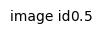

In [159]:
from matplotlib.widgets import Slider

fig = plt.figure()

ax = fig.add_axes([0, 0, 0, 0])

image_id_slider = Slider(
    valmin=0,
    valmax=117,
    ax=ax,
    label="image id"
)

plt.imshow(one_exp_data.get_stimulus_template(stimulus_name='natural_scenes')[1], cmap='gray')